# Notebook 00c — Inspect ECB Data

**Purpose:** Detailed inspection of the 4 series from the European Central Bank.

## Series Inspected

| Series | Frequency | Role |
|---|---|---|
| eurusd_official | daily | EUR/USD official ECB rate (cross-validation) |
| eur_effective_rate | monthly | EUR strength vs 40 trading partners |
| euribor_3m | monthly | EU interbank benchmark rate |
| ester_overnight | daily | EU overnight rate (replaced EONIA, from 2019) |

## Why ECB

- Official EUR data from the **primary source** (not a mirror)
- EU-specific rates not available in FRED
- Cross-validation for EUR/USD

**Output:** Charts saved to `figures/data_inspection/ecb/`

---

**Author:** Dong Cong Gia Khang  
**Date:** May 2026

## 1. Setup

In [1]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ecb"
FIG_DIR = PROJECT_ROOT / "figures" / "data_inspection" / "ecb"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Figures:      {FIG_DIR}")

Project root: d:\Final Project 2
Raw data:     d:\Final Project 2\data\raw\ecb
Figures:      d:\Final Project 2\figures\data_inspection\ecb


## 2. Inspection Helper Function

Reusable function. ECB CSVs have format: `date, <series_name>`.

In [2]:
"""
Helper function to inspect one ECB series.
"""
def inspect_ecb_series(name, description, frequency, category):
    """Inspect a single ECB series. Returns summary dict."""
    df = pd.read_csv(RAW_DIR / f"{name}.csv")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    series = df[name]

    print(f"\n{'='*70}")
    print(f"  {name}  ({frequency} | {category})")
    print(f"{'='*70}")
    print(f"Description: {description}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"Missing: {series.isnull().sum()} ({series.isnull().sum()/len(series)*100:.1f}%)")
    print(f"\nStatistics:")
    print(f"  mean:   {series.mean():12.4f}")
    print(f"  std:    {series.std():12.4f}")
    print(f"  min:    {series.min():12.4f}")
    print(f"  max:    {series.max():12.4f}")
    print(f"  latest: {series.dropna().iloc[-1]:12.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    ax1.plot(df["date"], series, color="darkblue", linewidth=0.8)
    ax1.set_title(f"{name} — Time Series", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel(name)
    ax1.grid(True, alpha=0.3)

    ax2.hist(series.dropna(), bins=50, color="cornflowerblue", alpha=0.7, edgecolor="white")
    ax2.axvline(series.mean(), color="red", linestyle="--", linewidth=1,
                label=f"mean={series.mean():.2f}")
    ax2.axvline(series.median(), color="green", linestyle="--", linewidth=1,
                label=f"median={series.median():.2f}")
    ax2.set_title(f"{name} — Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel(name)
    ax2.set_ylabel("Frequency")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = FIG_DIR / f"{name}.png"
    plt.savefig(out_path)
    plt.show()
    print(f"\nSaved: {out_path.relative_to(PROJECT_ROOT)}")

    return {
        "series": name,
        "rows": len(df),
        "missing": int(series.isnull().sum()),
        "mean": round(series.mean(), 4),
        "std": round(series.std(), 4),
        "min": round(series.min(), 4),
        "max": round(series.max(), 4),
    }


print("Helper function defined ")

Helper function defined 


## 3. EUR/USD Official (Cross-Validation)

ECB's official daily reference rate (published 16:00 CET). Used to cross-check yfinance and FRED EUR/USD data.


  eurusd_official  (daily | exchange_rate)
Description: EUR/USD official reference rate from ECB (16:00 CET). For cross-validation with yfinance and FRED.
Shape: (4192, 2)
Date range: 2010-01-01 -> 2026-05-06
Missing: 9 (0.2%)

Statistics:
  mean:         1.1858
  std:          0.1109
  min:          0.9565
  max:          1.4882
  latest:       1.1762


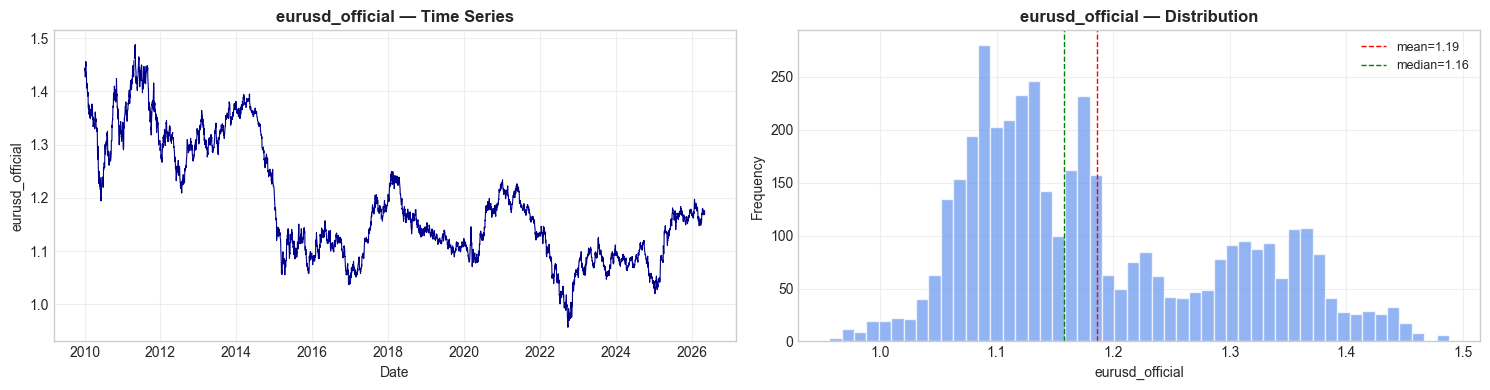


Saved: figures\data_inspection\ecb\eurusd_official.png


In [3]:
ecb_summaries = []

ecb_summaries.append(inspect_ecb_series(
    "eurusd_official",
    "EUR/USD official reference rate from ECB (16:00 CET). For cross-validation with yfinance and FRED.",
    "daily", "exchange_rate"))

## 4. EUR Effective Exchange Rate

Measures EUR strength against a basket of 40 trading partners — a broader measure than just EUR/USD.


  eur_effective_rate  (monthly | eur_strength)
Description: EUR Nominal Effective Exchange Rate (EER-40) vs 40 trading partners. Measures broad EUR strength.
Shape: (196, 2)
Date range: 2010-01-01 -> 2026-04-01
Missing: 0 (0.0%)

Statistics:
  mean:       116.1884
  std:          6.4265
  min:        102.2163
  max:        131.1460
  latest:     130.2448


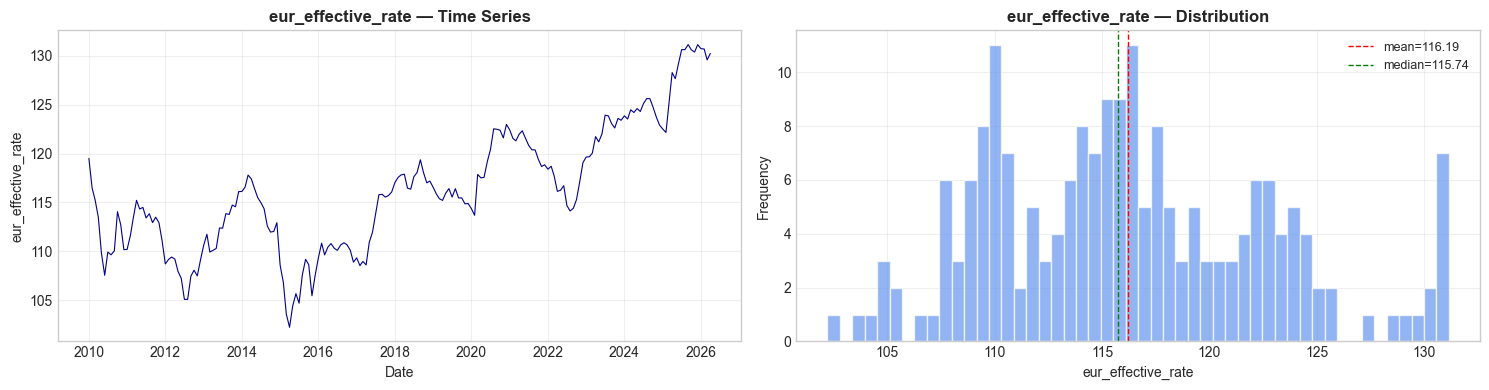


Saved: figures\data_inspection\ecb\eur_effective_rate.png


In [4]:
ecb_summaries.append(inspect_ecb_series(
    "eur_effective_rate",
    "EUR Nominal Effective Exchange Rate (EER-40) vs 40 trading partners. Measures broad EUR strength.",
    "monthly", "eur_strength"))

## 5. Euribor 3-Month

EU interbank lending benchmark rate. Tracks ECB policy closely.


  euribor_3m  (monthly | eu_rates)
Description: Euribor 3-Month. Benchmark interbank lending rate in the Eurozone.
Shape: (196, 2)
Date range: 2010-01-01 -> 2026-04-01
Missing: 0 (0.0%)

Statistics:
  mean:         0.6832
  std:          1.3286
  min:         -0.5820
  max:          3.9716
  latest:       2.1753


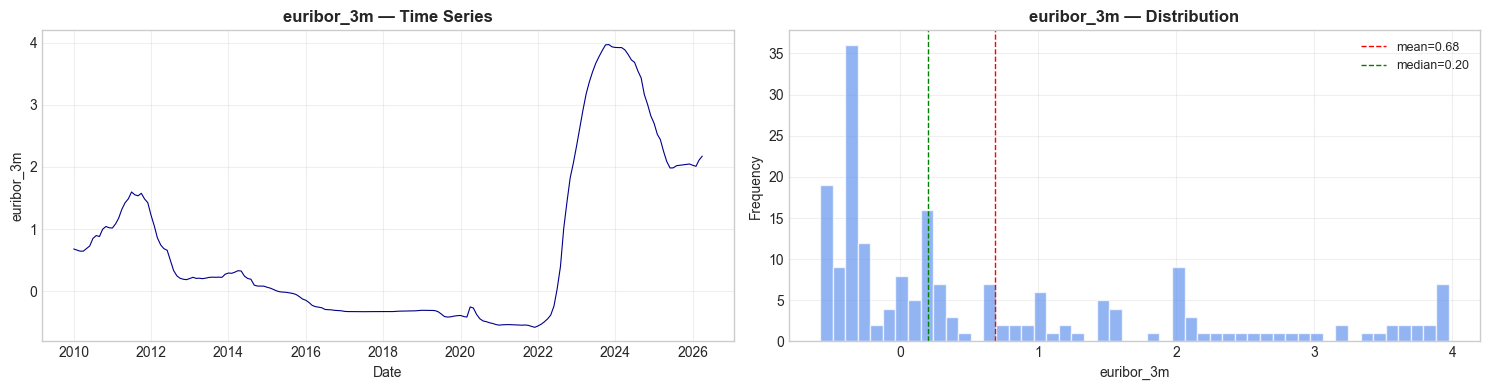


Saved: figures\data_inspection\ecb\euribor_3m.png


In [5]:
ecb_summaries.append(inspect_ecb_series(
    "euribor_3m",
    "Euribor 3-Month. Benchmark interbank lending rate in the Eurozone.",
    "monthly", "eu_rates"))

## 6. ESTER Overnight Rate

Euro Short-Term Rate — replaced EONIA from October 2019. **Note:** limited history (only from 2019).


  ester_overnight  (daily | eu_rates)
Description: ESTER overnight rate. Replaced EONIA from October 2019. Limited history.
Shape: (1688, 2)
Date range: 2019-10-01 -> 2026-05-06
Missing: 0 (0.0%)

Statistics:
  mean:         1.2728
  std:          1.7754
  min:         -0.5930
  max:          3.9130
  latest:       1.9310


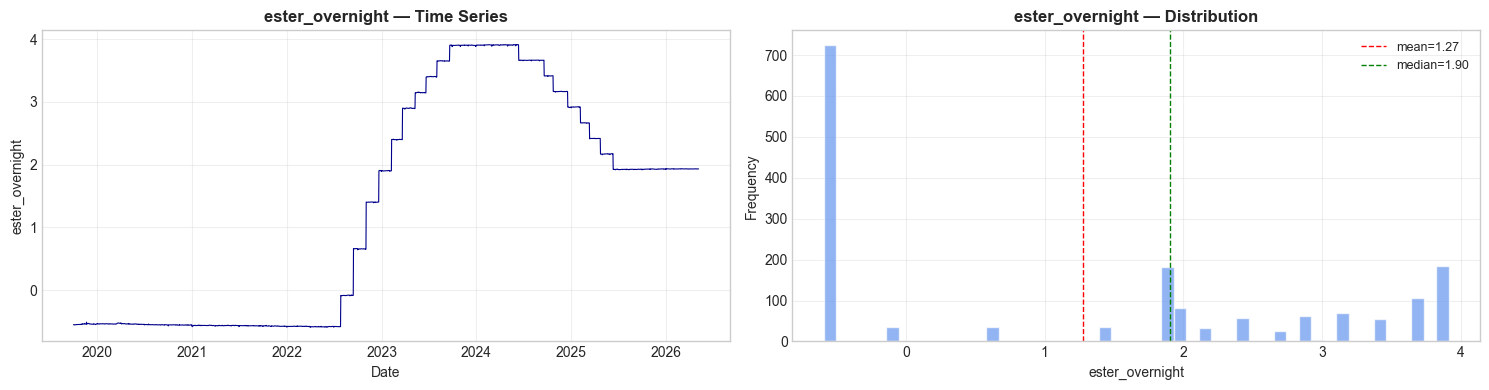


Saved: figures\data_inspection\ecb\ester_overnight.png


In [6]:
ecb_summaries.append(inspect_ecb_series(
    "ester_overnight",
    "ESTER overnight rate. Replaced EONIA from October 2019. Limited history.",
    "daily", "eu_rates"))

In [7]:
"""
Summary table of all 4 ECB series.
"""
summary_df = pd.DataFrame(ecb_summaries)

print("ECB SERIES SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

print(f"\nCharts saved in {FIG_DIR.relative_to(PROJECT_ROOT)}:")
for png in sorted(FIG_DIR.glob("*.png")):
    print(f"  - {png.name}")

ECB SERIES SUMMARY
            series  rows  missing     mean    std      min      max
   eurusd_official  4192        9   1.1858 0.1109   0.9565   1.4882
eur_effective_rate   196        0 116.1884 6.4265 102.2163 131.1460
        euribor_3m   196        0   0.6832 1.3286  -0.5820   3.9716
   ester_overnight  1688        0   1.2728 1.7754  -0.5930   3.9130

Charts saved in figures\data_inspection\ecb:
  - ester_overnight.png
  - eur_effective_rate.png
  - euribor_3m.png
  - eurusd_official.png


## Conclusion

### ECB Data Summary

 Inspected all **4 ECB series**  
 Charts saved to `figures/data_inspection/ecb/`

### Key Observations

- **eurusd_official:** nearly identical to yfinance/FRED EUR/USD (validation passed)
- **eur_effective_rate:** monthly, broad EUR strength measure
- **euribor_3m:** tracks ECB rate, negative during 2015-2022
- **ester_overnight:** only from Oct 2019 (will have many missing values in master dataset before 2019)

### Next

`00d_inspect_cot.ipynb` — inspect COT positioning data (final inspection notebook).